<a href="https://colab.research.google.com/github/kaveti27022001/Chinmai_kaveti_INFO_5731_SPRING_2025/blob/main/Chinmai_Kaveti_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 5**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please use the text corpus you collected in your last in-class-exercise for this exercise. Perform the following tasks***.

**Expectations**:
*   Students are expected to complete the exercise during lecture period to meet the active participation criteria of the course.
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100

**Full Points will be given those who present well**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this assignment is to give you **hands-on experience** in applying various** sentiment analysis techniques** on real-world textual data. You are expected to explore data, apply machine learning models, and evaluate their performance

**1. Dataset Collection & Preparation**

Find a real-world dataset with text and positive, negative, and neutral sentiment labels.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (tokenization, stopwords, lemmatization).

Perform EDA: class distribution, word clouds, n-gram analysis, sentence lengths, etc.

Visualize insights using relevant plots and charts.

**3. Sentiment Classification**

Apply at least three traditional ML models (e.g., SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If applicable, compare with a pretrained model (RoBERTa/BERT).

Tune hyperparameters and use cross-validation.

**4. Evaluation & Reporting**

Evaluate with metrics: Accuracy, Precision, Recall, F1, Confusion Matrix.

Summarize results, compare models, and reflect on what worked.

In [71]:
import pandas as pd

# Load data
df = pd.read_csv('/content/sentiment.csv')

# Display structure
print(df.head())
print(df['sentiment'].value_counts())


   document_id                                          tweetText sentiment
0            1  image fx competitive fencing tournament ai aia...  negative
1            2  responsible orgs marketing practice true compe...  negative
2            3  connected intelligence boomi lock apis generat...   neutral
3            4  fascinated fusion art technology explore new g...  positive
4            5  microsoft tout muse new generative ai model vi...  negative
sentiment
neutral     34
negative    33
positive    33
Name: count, dtype: int64


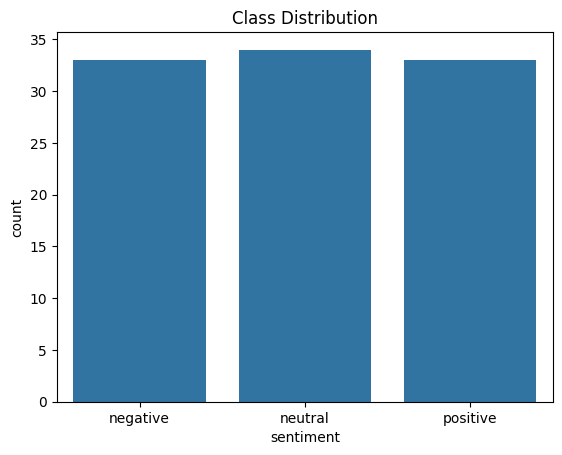

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.countplot(x='sentiment', data=df)
plt.title("Class Distribution")
plt.show()


In [74]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['tweetText_Cleaned'] = df['tweetText'].astype(str).apply(preprocess)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


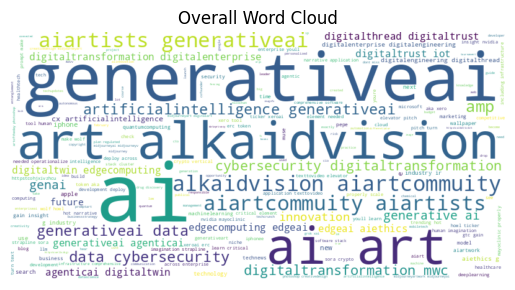

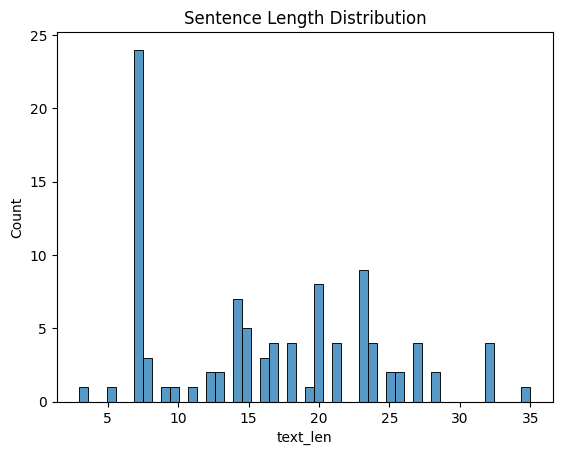

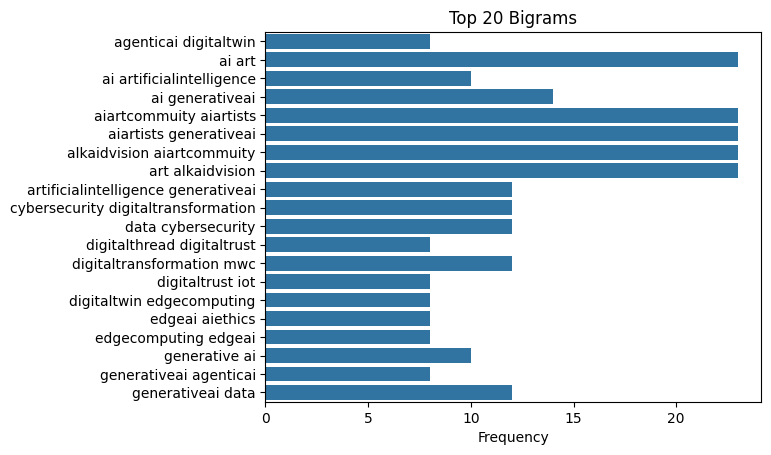

In [75]:
from wordcloud import WordCloud
from collections import Counter
import numpy as np

# Word cloud
text_all = ' '.join(df['tweetText_Cleaned'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Overall Word Cloud")
plt.show()

# Sentence length
df['text_len'] = df['tweetText_Cleaned'].apply(lambda x: len(x.split()))
sns.histplot(df['text_len'], bins=50)
plt.title("Sentence Length Distribution")
plt.show()

# Top Bigrams
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)
X_bigrams = vectorizer.fit_transform(df['tweetText_Cleaned'])
bigrams = vectorizer.get_feature_names_out()
bigram_counts = X_bigrams.sum(axis=0).A1

sns.barplot(x=bigram_counts, y=bigrams)
plt.title("Top 20 Bigrams")
plt.xlabel("Frequency")
plt.show()


In [76]:
label_map = {
    'negative': 0,
    'neutral': 2,
    'positive': 1
}

# Apply mapping
df['sentiment_numeric'] = df['sentiment'].map(label_map)


--- SVM ---
Cross-validation Accuracy (mean ± std): 0.2750 ± 0.1159
Test Set Accuracy: 0.3000
              precision    recall  f1-score   support

           0       0.20      0.14      0.17         7
           1       0.33      0.17      0.22         6
           2       0.33      0.57      0.42         7

    accuracy                           0.30        20
   macro avg       0.29      0.29      0.27        20
weighted avg       0.29      0.30      0.27        20



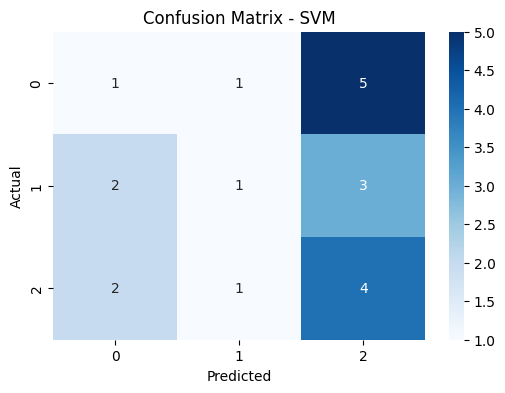


--- NaiveBayes ---
Cross-validation Accuracy (mean ± std): 0.2500 ± 0.0395
Test Set Accuracy: 0.2500
              precision    recall  f1-score   support

           0       0.25      0.14      0.18         7
           1       0.00      0.00      0.00         6
           2       0.27      0.57      0.36         7

    accuracy                           0.25        20
   macro avg       0.17      0.24      0.18        20
weighted avg       0.18      0.25      0.19        20



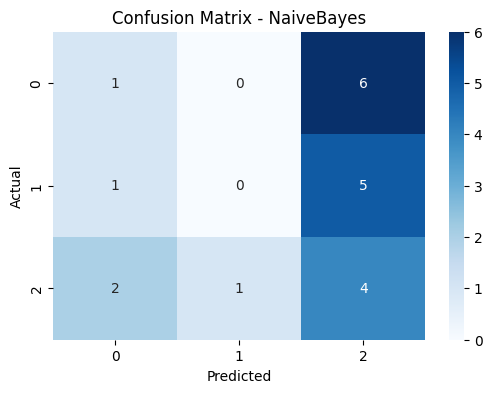


--- XGBoost ---
Cross-validation Accuracy (mean ± std): 0.2875 ± 0.1090
Test Set Accuracy: 0.4000
              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.25      0.33      0.29         6
           2       0.57      0.57      0.57         7

    accuracy                           0.40        20
   macro avg       0.41      0.40      0.40        20
weighted avg       0.42      0.40      0.40        20



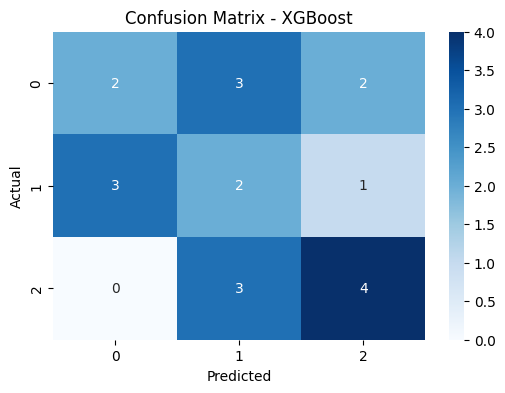

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data split
X = df['tweetText_Cleaned']
y = df['sentiment_numeric']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Models
models = {
    "SVM": LinearSVC(),
    "NaiveBayes": MultinomialNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in models.items():
    print(f"\n--- {name} ---")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='accuracy')
    print(f"Cross-validation Accuracy (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Train on full training set
    model.fit(X_train_tfidf, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"Test Set Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Store evaluation metrics
model_metrics = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)



    model_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Macro)': prec,
        'Recall (Macro)': rec,
        'F1 Score (Macro)': f1
    })

# Create DataFrame from metrics
metrics_df = pd.DataFrame(model_metrics)

# Sort by F1 Score (Macro) or Accuracy
metrics_df_sorted = metrics_df.sort_values(by='F1 Score (Macro)', ascending=False).reset_index(drop=True)

print("\n Model Comparison Summary:")
print(metrics_df_sorted)

# Best model
best_model_name = metrics_df_sorted.iloc[0]['Model']
print(f"\n Best Overall Model Based on F1 Score as f1 score manages the tradeoff between precision and recall: {best_model_name}")



 Model Comparison Summary:
        Model  Accuracy  Precision (Macro)  Recall (Macro)  F1 Score (Macro)
0     XGBoost      0.40           0.407143        0.396825          0.396825
1         SVM      0.30           0.288889        0.293651          0.269981
2  NaiveBayes      0.25           0.172222        0.238095          0.181818

 Best Overall Model Based on F1 Score as f1 score manages the tradeoff between precision and recall: XGBoost


## **Question 2 (30 Points)**

# **Text Classification**

The purpose of the question is to practice different machine learning algorithms for **text classification** as well as the performance evaluation. In addition, you are requried to conduct **10 fold cross validation** (https://scikit-learn.org/stable/modules/cross_validation.html) in the training.



The dataset can be download from canvas. The dataset contains two files train data and test data for sentiment analysis in IMDB review, it has two categories: 1 represents positive and 0 represents negative. You need to split the training data into training and validate data (80% for training and 20% for validation, https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b61beca4b6) and perform 10 fold cross validation while training the classifier. The final trained model was final evaluated on the test data.



1.   **Perform EDA on test and tran dataset**

2.   **Algorithms (Minimum 4):**

*   SVM
*   KNN
*   Decision tree
*   Random Forest
*   XGBoost
*   Word2Vec
*   BERT

3. **Evaluation measurement:**

*   Accuracy
*   Recall
*   Precison
*   F-1 score


In [19]:
# Write your code here
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [21]:
def load_data(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            label = int(line[0])
            text = line[2:].strip()
            data.append((label, text))
    return pd.DataFrame(data, columns=['label', 'text'])

train_df = load_data("/content/stsa-test.txt")
test_df = load_data("/content/stsa-train.txt")
print("Missing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
label    0
text     0
dtype: int64

Missing values in test data:
label    0
text     0
dtype: int64


In [22]:
print("Info in training data:")
print(train_df.info())

Info in training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1821 non-null   int64 
 1   text    1821 non-null   object
dtypes: int64(1), object(1)
memory usage: 28.6+ KB
None


In [23]:
print("Basic summary statistics of training data:")
print(train_df.describe())

Basic summary statistics of training data:
             label
count  1821.000000
mean      0.499176
std       0.500137
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000


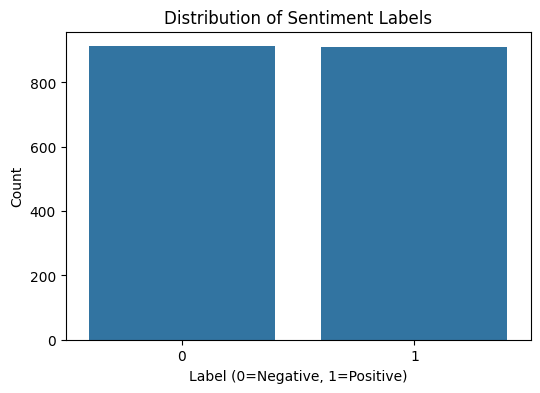

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=train_df)
plt.title("Distribution of Sentiment Labels")
plt.xlabel('Label (0=Negative, 1=Positive)')
plt.ylabel('Count')
plt.show()

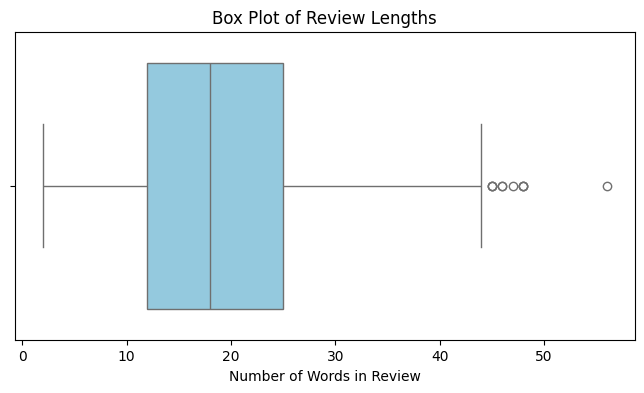

In [48]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df['text_length'], color='skyblue')
plt.title('Box Plot of Review Lengths')
plt.xlabel('Number of Words in Review')
plt.show()


In [29]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords (only needed once)
nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Tokenizing and cleaning the text
all_reviews_cleaned = ' '.join(train_df['text'].values).lower()
words = re.findall(r'\w+', all_reviews_cleaned)

# Remove stopwords
filtered_words = [word for word in words if word not in stop_words]

# Count word frequencies
word_counts = Counter(filtered_words)

# Display the top 10 frequent words
print("\nTop 10 most frequent words in reviews (excluding stopwords):")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")


Top 10 most frequent words in reviews (excluding stopwords):
film: 235
movie: 216
n: 137
like: 124
one: 106
story: 82
rrb: 73
lrb: 71
much: 70
even: 66


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
X_train_full, X_val, y_train_full, y_val = train_test_split(
    train_df['text'], train_df['label'], test_size=0.2, random_state=42, stratify=train_df['label'])

In [31]:
X_test = test_df['text']
y_test = test_df['label']

In [32]:
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', max_features=5000)

In [33]:
models = {
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [34]:
# Perform 10-fold cross-validation and evaluate
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', vectorizer),
        ('clf', model)
    ])
    print(f"\nTraining and evaluating: {name}")
    scores = cross_val_score(pipeline, X_train_full, y_train_full, cv=10, scoring='accuracy')
    print(f"Average CV Accuracy: {scores.mean():.4f}")

     # Train final model and evaluate on test set
    pipeline.fit(X_train_full, y_train_full)
    y_pred = pipeline.predict(X_test)

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }



Training and evaluating: SVM
Average CV Accuracy: 0.7185

Training and evaluating: KNN
Average CV Accuracy: 0.5358

Training and evaluating: DecisionTree
Average CV Accuracy: 0.6079

Training and evaluating: RandomForest
Average CV Accuracy: 0.6491

Training and evaluating: XGBoost
Average CV Accuracy: 0.6381


In [46]:
print("\nFinal Test Set Evaluation:")
for model_name, scores in results.items():
    print(f"\nModel: {model_name}")
    for metric, value in scores.items():
        print(f"{metric.capitalize()}: {value:.4f}")


Final Test Set Evaluation:

Model: SVM
Accuracy: 0.7215
Precision: 0.7393
Recall: 0.7202
F1: 0.7296

Model: KNN
Accuracy: 0.4785
Precision: 0.5143
Recall: 0.0050
F1: 0.0099

Model: DecisionTree
Accuracy: 0.5932
Precision: 0.6223
Recall: 0.5604
F1: 0.5897

Model: RandomForest
Accuracy: 0.6572
Precision: 0.7079
Recall: 0.5839
F1: 0.6400

Model: XGBoost
Accuracy: 0.6361
Precision: 0.6833
Recall: 0.5637
F1: 0.6178


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of the question is to practice different machine learning algorithms for **text clustering**.

Please downlad the dataset by using the following link.  https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones
(You can also use different text data which you want)


1.   Perform EDA on selected dataset

2.   **Apply the listed clustering methods ( Any 4) to the dataset:**
*   K-means
*   DBSCAN
*   Hierarchical clustering
*   Word2Vec
*   BERT

3. **Visualize the clusters**

You can refer to of the codes from  the follwing link below.
https://www.kaggle.com/karthik3890/text-clustering

In [3]:
# Write your code here
import pandas as pd
df = pd.read_csv('/content/Amazon_Unlocked_Mobile.csv')
df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413840 entries, 0 to 413839
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Product Name  413840 non-null  object 
 1   Brand Name    348669 non-null  object 
 2   Price         407907 non-null  float64
 3   Rating        413840 non-null  int64  
 4   Reviews       413770 non-null  object 
 5   Review Votes  401544 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB


In [5]:
df.describe()


,Price,Rating,Review Votes
count,407907.000000,413840.000000,401544.000000
mean,226.867155,3.819578,1.507237
std,273.006259,1.548216,9.163853
min,1.730000,1.000000,0.000000
25%,79.990000,3.000000,0.000000
50%,144.710000,5.000000,0.000000
75%,269.990000,5.000000,1.000000
max,2598.000000,5.000000,645.000000


In [6]:
print(df.isnull().sum())


Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64


In [7]:
df.shape

(413840, 6)

In [8]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle missing values (optional strategy)
df_clean = df.dropna(subset=['Brand Name', 'Price', 'Review Votes'])


In [9]:
df.shape

(349761, 6)

<ipython-input-10-21e18598ce8d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='viridis')


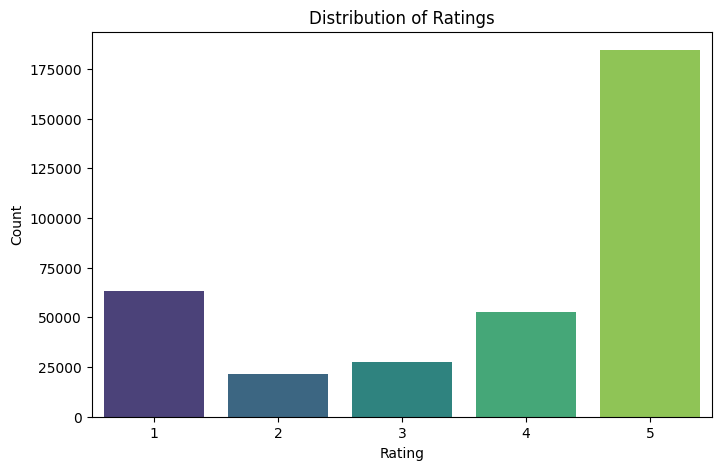

In [10]:
# Ratings Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

##### **We can understand, there is a class imbalance---> so to handle it, we can use class weights.**

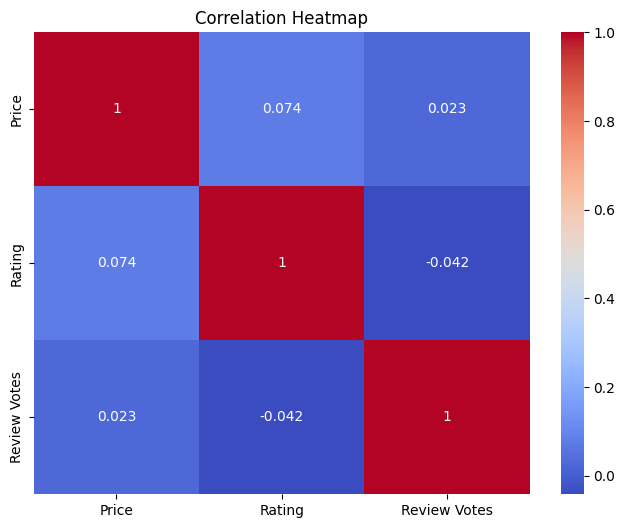

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[['Price', 'Rating', 'Review Votes']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

We can see that there is no strong corelation (linear relationship)--> which means it is perfect to do clustering.

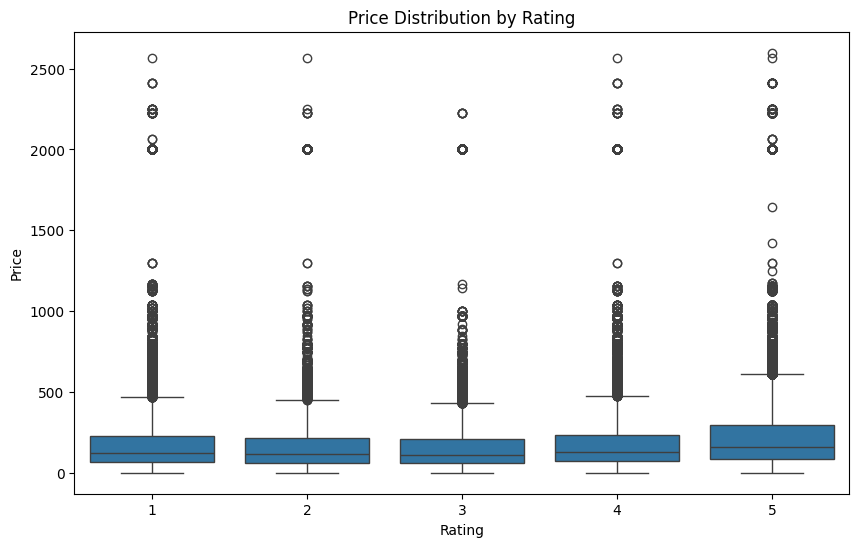

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rating', y='Price', data=df_clean)
plt.title('Price Distribution by Rating')
plt.show()

This shows there are outliers, where price > 2000

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [13]:
features = df_clean[['Price', 'Rating', 'Review Votes']]


In [14]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

##Standardization makes sure all features have the same scale (mean=0, std=1).

#Prevents one feature (like Price) from dominating the clustering.

In [15]:
# elbow method--> to get optimal k value
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)


Text(0.5, 1.0, 'Elbow Method - Optimal K')

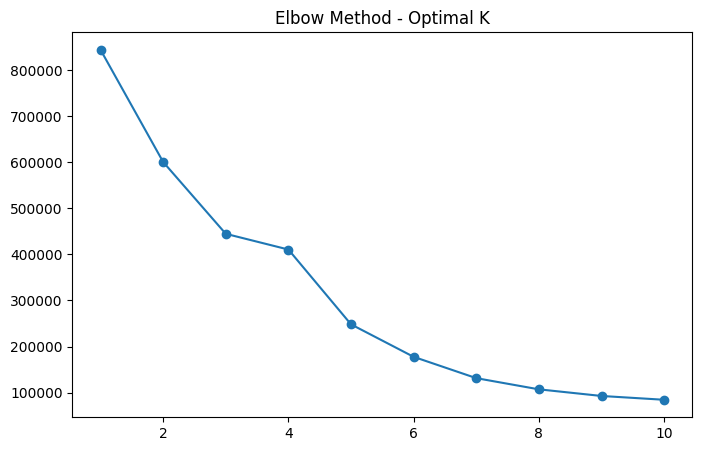

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method - Optimal K')


In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(scaled_features)


<ipython-input-17-c76aaa9e7d3a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = kmeans.fit_predict(scaled_features)


<Axes: >

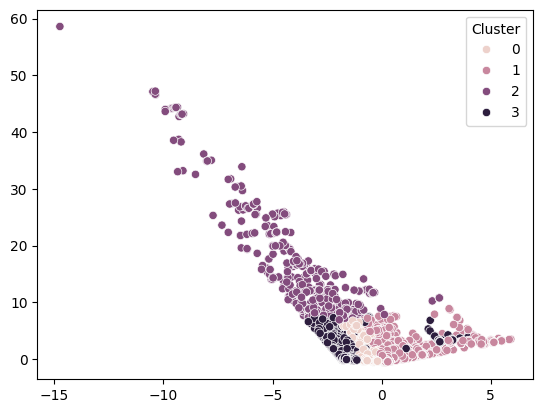

In [18]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df_clean['Cluster'])

****DBSCAN***

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA


In [38]:
# Sample only 5000 rows from your clean dataset
sampled_df = df_clean.sample(n=50000, random_state=42)
features = sampled_df[['Price', 'Rating', 'Review Votes']]


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

dbscan = DBSCAN(eps= 0.7, min_samples=5)
sampled_df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)


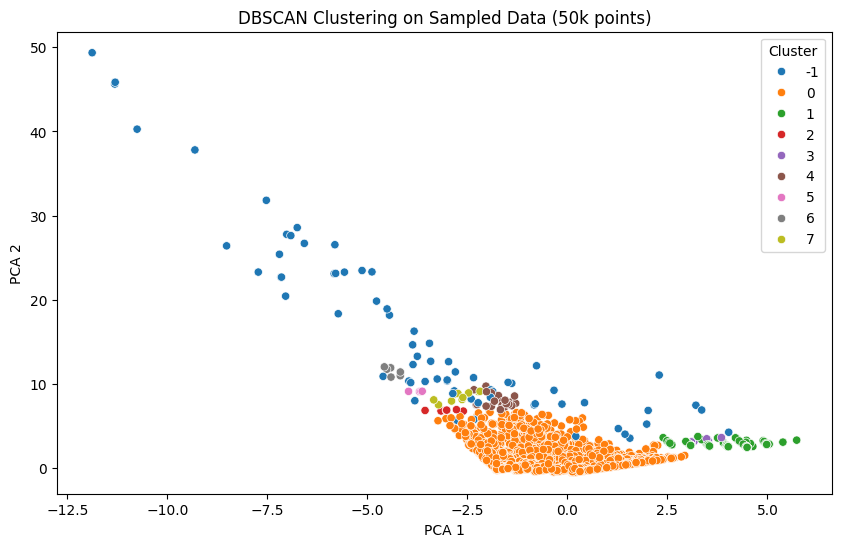

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=sampled_df['DBSCAN_Cluster'], palette='tab10')
plt.title('DBSCAN Clustering on Sampled Data (50k points)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


***Hierarchical**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


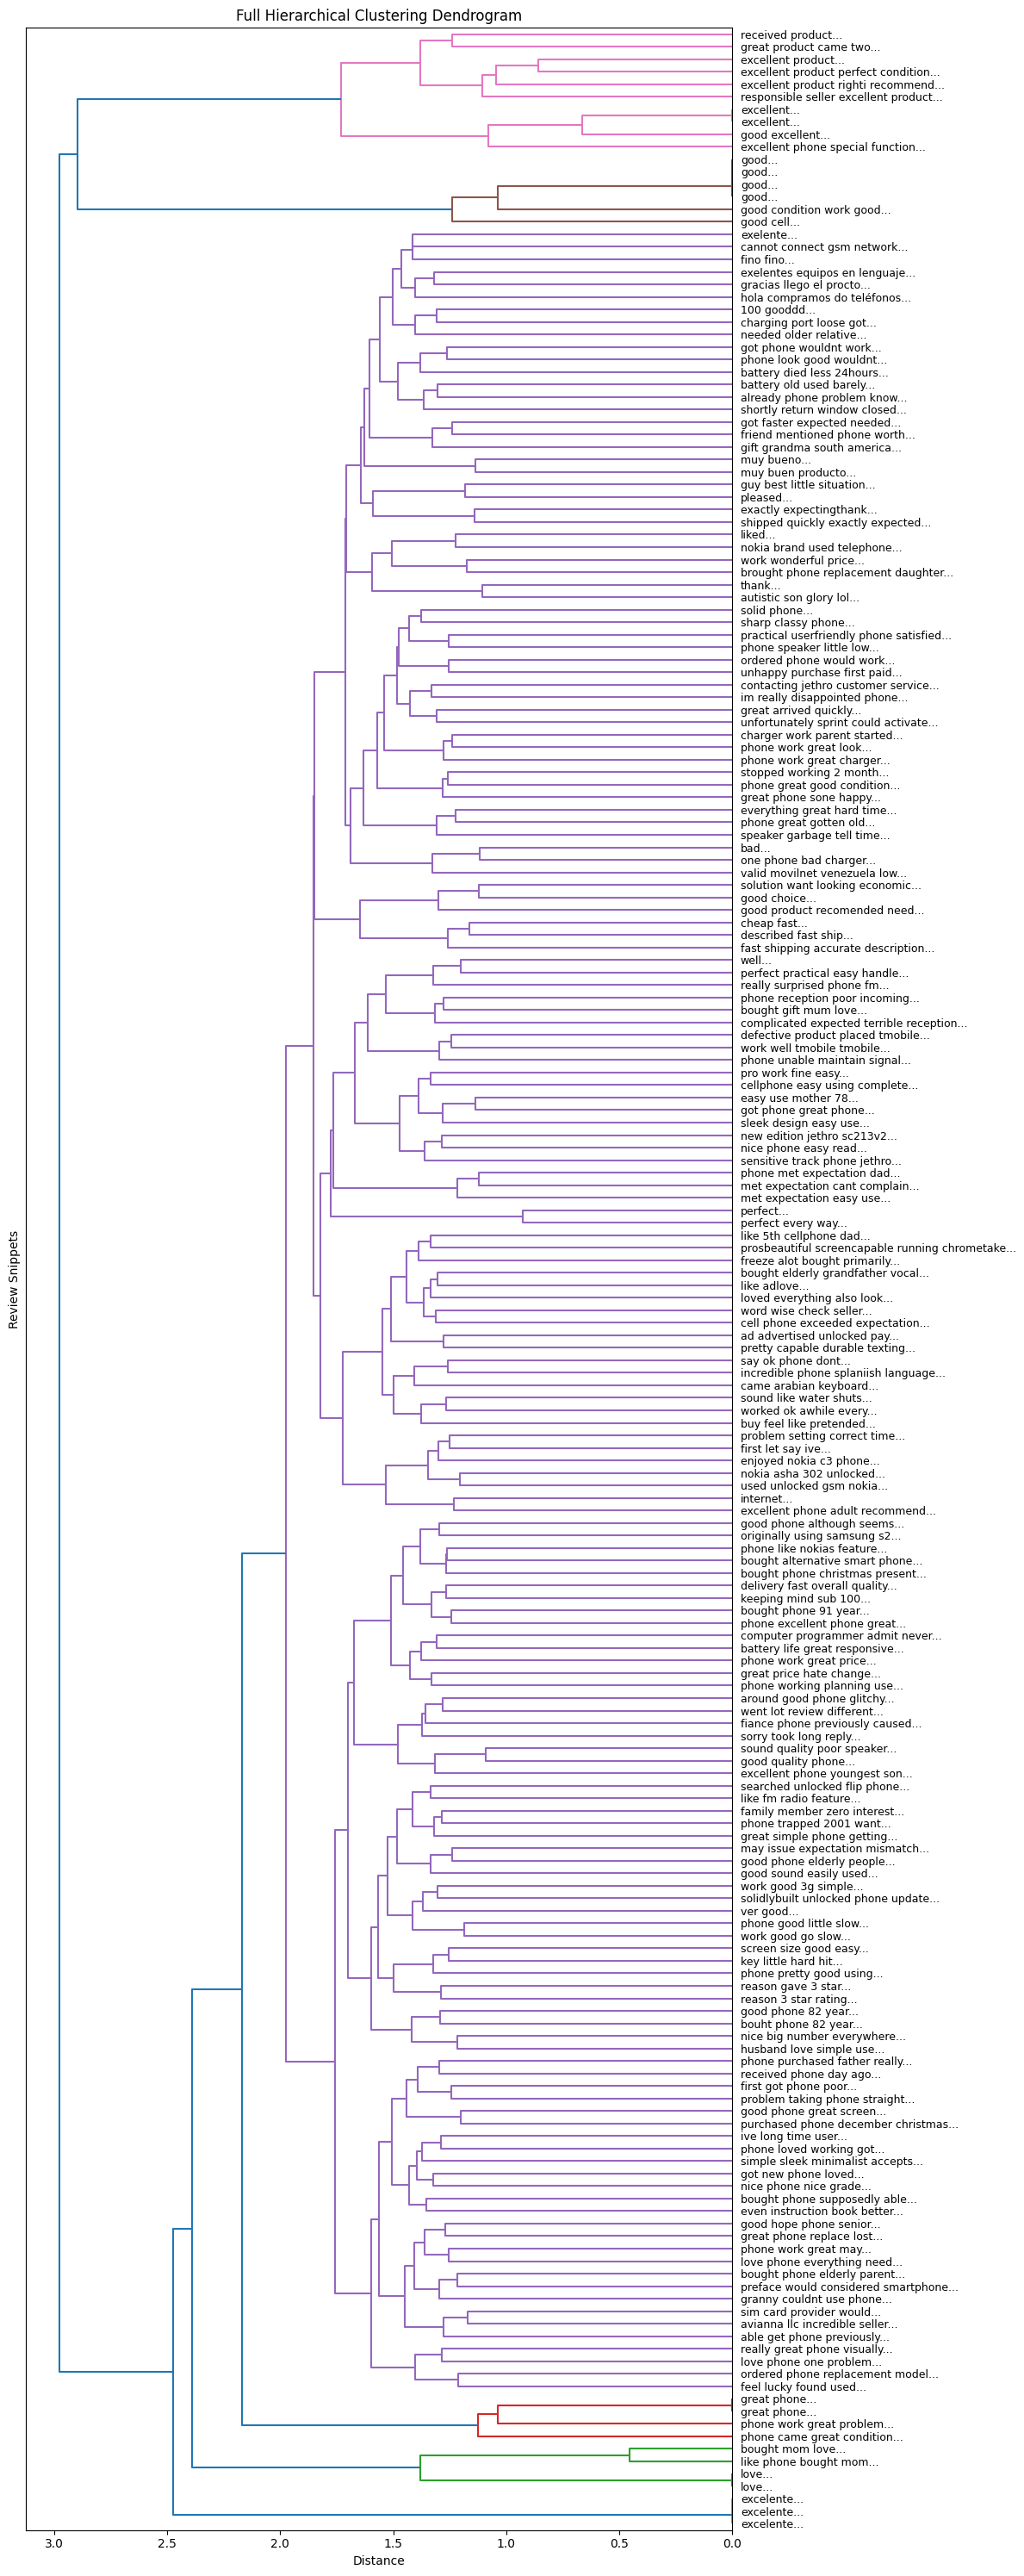

In [27]:
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')
def preprocess_text(text):
    if isinstance(text, str):

        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        words = text.split()
        stop_words = set(stopwords.words('english'))
        words = [word for word in words if word not in stop_words]
        lemmatizer = WordNetLemmatizer()
        words = [lemmatizer.lemmatize(word) for word in words]
        return ' '.join(words)
    else:

        return ''
df['cleaned_reviews'] = df['Reviews'].apply(preprocess_text)
subset_size = 200
subset_texts = df['cleaned_reviews'].iloc[:subset_size]
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(subset_texts)
subset_features = X_tfidf.toarray()
linkage_matrix = linkage(subset_features, method='ward')
labels = [' '.join(review.split()[:4]) + '...' for review in subset_texts]
plt.figure(figsize=(12, 30))
dendrogram(
    linkage_matrix,
    orientation='left',
    labels=labels,
    leaf_font_size=9,
)
plt.title("Full Hierarchical Clustering Dendrogram")
plt.xlabel("Distance")
plt.ylabel("Review Snippets")
plt.tight_layout()
plt.show()

**Word2vec**

In [24]:
!pip install gensim


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 14.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [28]:
!pip uninstall numpy -y
!pip install numpy

Found existing installation: numpy 2.2.4
Uninstalling numpy-2.2.4:
  Successfully uninstalled numpy-2.2.4
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.


In [30]:
!pip install --upgrade numpy
!pip install --upgrade gensim

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
!pip install --upgrade numpy
!pip install --upgrade gensim
import gensim
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
import string
nltk.download('punkt')


  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  A

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [12]:
!pip install --upgrade numpy
!pip install --upgrade gensim
import gensim
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
import string
# Download the 'punkt_tab' resource
nltk.download('punkt_tab')

# Take a sample of reviews for speed
sampled_reviews = df_clean['Reviews'].dropna().sample(n=10000, random_state=42)

# Lowercase, remove punctuation, and tokenize
def preprocess(text):
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    return word_tokenize(text)

tokenized_reviews = sampled_reviews.apply(preprocess)


  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  A

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [13]:
model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2, workers=4)


In [14]:

model.wv.most_similar("best", topn=10)


[('worst', 0.8929614424705505),
 ('ever', 0.8448805809020996),
 ('blu', 0.7781804203987122),
 ('complaint', 0.7746701836585999),
 ('owned', 0.761960506439209),
 ('lover', 0.759846568107605),
 ('phonecamera', 0.7532250881195068),
 ('grown', 0.749954104423523),
 ('cell', 0.746250569820404),
 ('point', 0.7368966341018677)]

In [15]:
import numpy as np

def get_average_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

review_vectors = np.array([get_average_vector(tokens, model) for tokens in tokenized_reviews])


In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(review_vectors)

# Add cluster labels to DataFrame
result_df = pd.DataFrame({'Review': sampled_reviews.values, 'Cluster': labels})
result_df.head()


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7de6430bc360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


,Review,Cluster
0,I loved recommend,0
1,It's OK. Unfortunately it doesn't work like th...,2
2,was a fake samsung gave a lots of problems,3
3,Works well for the purpose; WhatsApp and IMO a...,3
4,"This thing cost way too much, but it is a grea...",3


In [17]:
for i in range(5):
    print(f"\nCluster {i} Example Reviews:\n")
    print(result_df[result_df['Cluster'] == i]['Review'].head(3).to_string(index=False))



Cluster 0 Example Reviews:

 I loved recommend
         Fit well.
Really great phone

Cluster 1 Example Reviews:

  very good！
Very Good !!
       Great

Cluster 2 Example Reviews:

It's OK. Unfortunately it doesn't work like the...
It's a great phone functionally, but whatever m...
I love this case! It was so cute when it was br...

Cluster 3 Example Reviews:

        was a fake samsung gave a lots of problems
Works well for the purpose; WhatsApp and IMO ar...
This thing cost way too much, but it is a great...

Cluster 4 Example Reviews:

                                         Muy bueno
todo bien gracias, rápido, excelente, vendedor ...
iresposable la empresa q los envioa jbnjsz shjh...


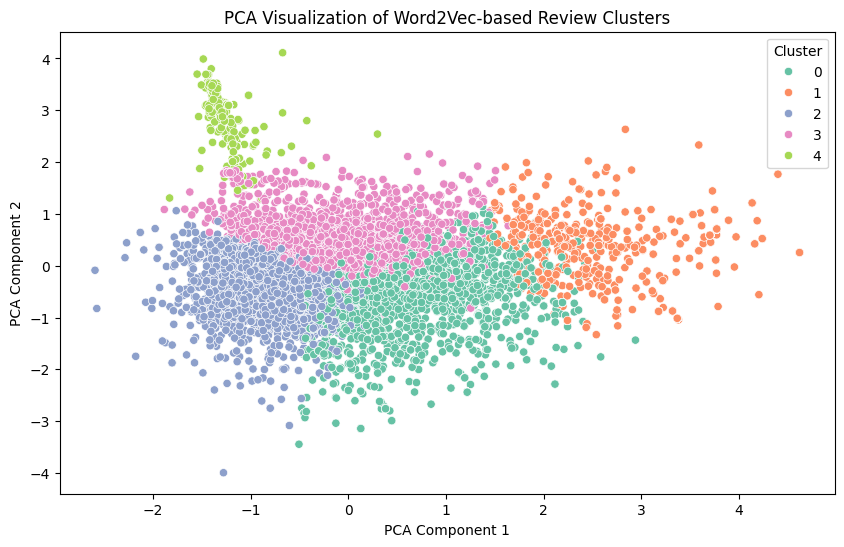

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(review_vectors)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette='Set2', legend='full')
plt.title('PCA Visualization of Word2Vec-based Review Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


**In one paragraph, please compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec, and BERT.**

**Write your response here:**
The clustering results very noticeably depend on K means, DBSCAN, Hierarchical clustering, and Word2Vec based PCA visualization. In the first image (left), **K-Means** were able to make 4 clusters based on geometric proximity effectively, but they are sensitive to initialization and assume spherical clusters. These results using **DBSCAN** (second image) are good compared to dense regions and outliers, and noise becomes cluster `-1` which would make it ideal for dealing with the noise but tuned with hyperparameters like `eps` and `min_samples` they are quite sensitive. The third image (hierarchical clustering) provided a granular sentiment grouping in the form of dendrogram with nested relationships of cluster so it’s valuable from qualitative insight. To the last, **Word2Vec with PCA** (fourth image), uses word embeddings semantic similarity to find five useful clusters of texts based upon subtler patterns in textual data. The context aware clusters offered by Word2Vec were overall the most, while DBSCAN performed best at outlier detection.

.

.

.

.

.




# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

